GDP growth data shape: (255, 1)


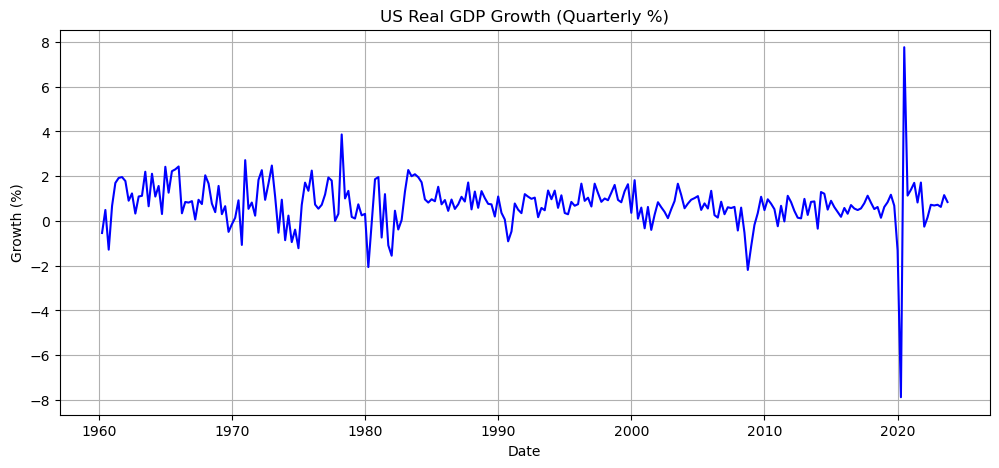

Fitting Markov switching model...
                        Markov Switching Model Results                        
Dep. Variable:             GDP Growth   No. Observations:                  255
Model:               MarkovRegression   Log Likelihood                -310.325
Date:                Fri, 13 Mar 2026   AIC                            632.651
Time:                        19:35:11   BIC                            653.899
Sample:                    04-01-1960   HQIC                           641.198
                         - 10-01-2023                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7616      0.044     17.326      0.000       0.675       0.848
sigma2         0.2

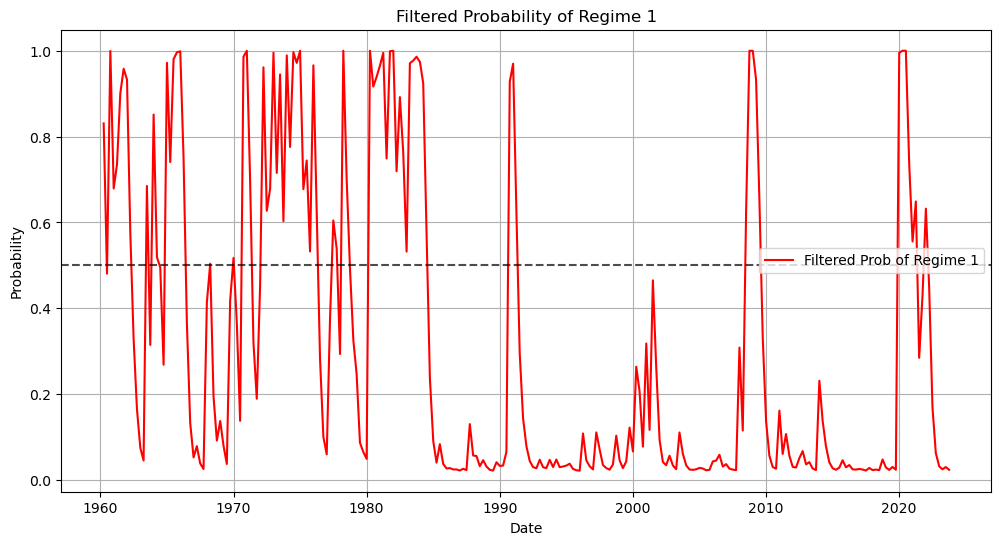

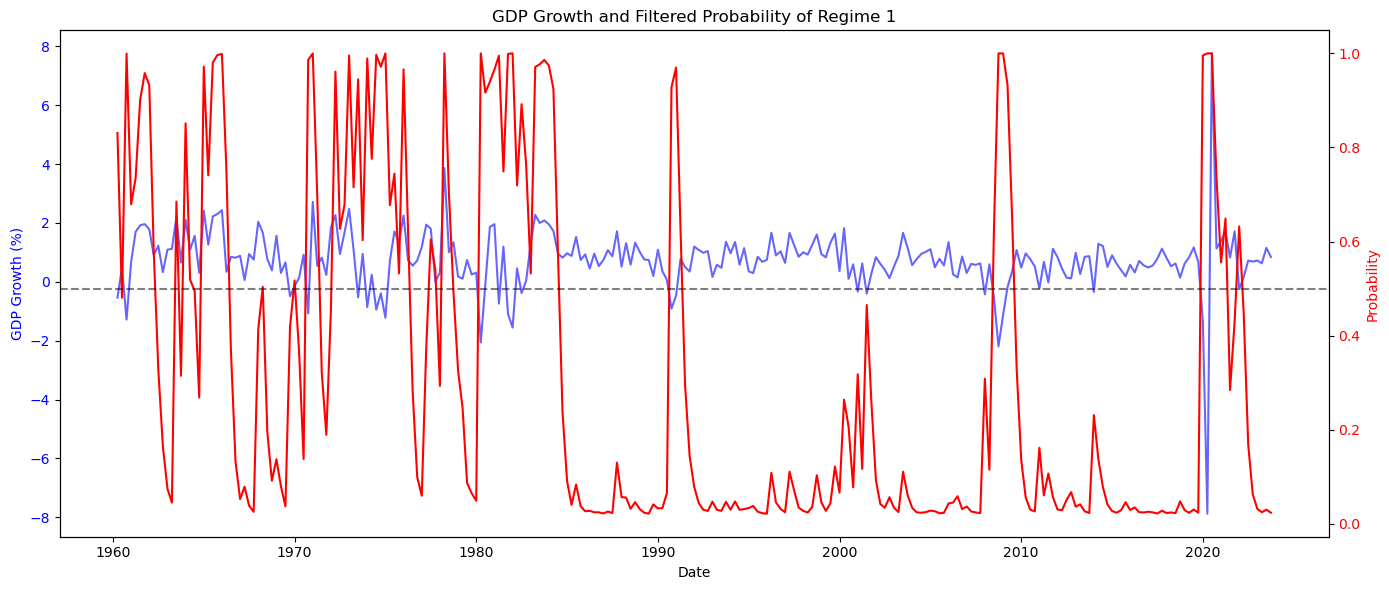

[*********************100%***********************]  2 of 2 completed


Good regime (higher mean) is Regime 0: mean = 0.76%, volatility = 0.47%



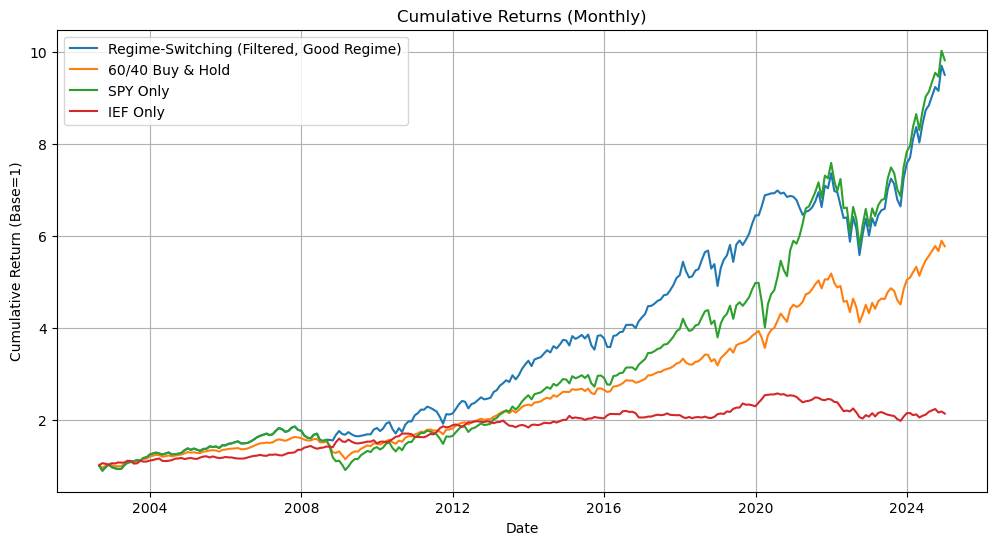


========== BACKTEST PERFORMANCE (2002–2024) ==========
Regime-Switch  : Ann Ret = 10.57%, Ann Vol = 12.43%, Sharpe = 0.85, Max DD = 177.91%
60/40          : Ann Ret = 8.14%, Ann Vol = 9.03%, Sharpe = 0.90, Max DD = 106.44%
SPY            : Ann Ret = 10.73%, Ann Vol = 14.83%, Sharpe = 0.72, Max DD = 181.75%
IEF            : Ann Ret = 3.46%, Ann Vol = 6.77%, Sharpe = 0.51, Max DD = 59.81%

✅ Done.


In [19]:
# ============================================================
# PROJECT 4: MACROECONOMIC REGIME-SWITCHING MODEL (CORRECTED)
# ============================================================
import numpy as np
import pandas as pd
import yfinance as yf
import pandas_datareader.data as web
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 1. FETCH MACROECONOMIC DATA (QUARTERLY GDP GROWTH)
# ============================================================
start = '1960-01-01'
end = '2023-12-31'

# Download real GDP (quarterly, billions of chained 2012 dollars)
gdp = web.DataReader('GDPC1', 'fred', start=start, end=end)
# Convert to quarterly growth rate (percent change)
gdp_growth = gdp.pct_change() * 100
gdp_growth = gdp_growth.dropna()
gdp_growth.columns = ['GDP Growth']

print("GDP growth data shape:", gdp_growth.shape)
gdp_growth.tail()

# Plot the GDP growth series
plt.figure(figsize=(12,5))
plt.plot(gdp_growth.index, gdp_growth, color='blue')
plt.title('US Real GDP Growth (Quarterly %)')
plt.xlabel('Date')
plt.ylabel('Growth (%)')
plt.grid(True)
plt.show()

# ============================================================
# 2. FIT A MARKOV SWITCHING MODEL (2 REGIMES, SWITCHING MEAN AND VARIANCE)
# ============================================================
model = MarkovRegression(gdp_growth, k_regimes=2, trend='c', switching_variance=True)
print("Fitting Markov switching model...")
result = model.fit()
print(result.summary())

# ============================================================
# 3. EXTRACT REGIME PROBABILITIES (FILTERED FOR REALISTIC BACKTEST)
# ============================================================
# Filtered probabilities (using only past data at each point)
filtered_probs = result.filtered_marginal_probabilities
filtered_probs.columns = ['Regime 0', 'Regime 1']

# Smoothed probabilities (for characterisation only)
smoothed_probs = result.smoothed_marginal_probabilities
smoothed_probs.columns = ['Regime 0', 'Regime 1']

# Plot filtered probabilities
plt.figure(figsize=(12,6))
plt.plot(filtered_probs.index, filtered_probs['Regime 1'], color='red', label='Filtered Prob of Regime 1')
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.7)
plt.title('Filtered Probability of Regime 1')
plt.xlabel('Date')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()

# Overlay on GDP growth
fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(gdp_growth.index, gdp_growth, color='blue', alpha=0.6, label='GDP Growth')
ax1.set_xlabel('Date')
ax1.set_ylabel('GDP Growth (%)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(filtered_probs.index, filtered_probs['Regime 1'], color='red', label='Regime 1 Prob')
ax2.set_ylabel('Probability', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5)
plt.title('GDP Growth and Filtered Probability of Regime 1')
fig.tight_layout()
plt.show()

# ============================================================
# 4. IDENTIFY THE "GOOD" REGIME (HIGHER MEAN)
# ============================================================
# Extract means
mean_0 = result.params['const[0]']
mean_1 = result.params['const[1]']

if mean_0 > mean_1:
    good_regime = 0
    print(f"\nGood regime (higher mean) is Regime 0: mean = {mean_0:.2f}%, volatility = {np.sqrt(result.params['sigma2[0]']):.2f}%")
else:
    good_regime = 1
    print(f"\nGood regime (higher mean) is Regime 1: mean = {mean_1:.2f}%, volatility = {np.sqrt(result.params['sigma2[1]']):.2f}%")

# Probability of being in the good regime (filtered)
prob_good = filtered_probs.iloc[:, good_regime]

# ============================================================
# 5. ASSET ALLOCATION STRATEGY USING FILTERED PROBABILITIES
# ============================================================
# We'll use monthly data for SPY (stocks) and IEF (bonds) from 2002.
start_assets = '2002-01-01'
end_assets = '2024-12-31'

print("\nDownloading asset price data...")
prices = yf.download(['SPY', 'IEF'], start=start_assets, end=end_assets, auto_adjust=True)['Close']
prices = prices.dropna()

# Compute monthly returns (end of month)
monthly_prices = prices.resample('M').last()
monthly_returns = monthly_prices.pct_change().dropna()

# Align filtered probabilities (quarterly) to monthly frequency
# We forward-fill the last known quarterly probability, but also account for data lag:
# GDP for a quarter is released about one month after the quarter ends.
# For simplicity, we shift the probability by 1 month to approximate the release lag.
# In practice, you'd want to use the probability available at the beginning of the month.
# We'll reindex and then shift by 1 month.

# First, get the quarterly probability series (end-of-quarter)
prob_good_quarterly = prob_good  # already indexed at quarter end
# Reindex to monthly dates, forward-fill
monthly_dates = monthly_returns.index
prob_good_monthly = prob_good_quarterly.reindex(monthly_dates, method='ffill').fillna(method='bfill')
# Shift by 1 month to account for release lag (GDP data for quarter ending March is known in April)
prob_good_monthly = prob_good_monthly.shift(1).fillna(method='bfill')

# Strategy: if prob_good > 0.5, invest in SPY; else invest in IEF.
strategy_returns = pd.Series(index=monthly_returns.index, dtype=float)
for i, date in enumerate(monthly_returns.index):
    prob = prob_good_monthly.loc[date]
    if prob > 0.5:
        strategy_returns.iloc[i] = monthly_returns.loc[date, 'SPY']
    else:
        strategy_returns.iloc[i] = monthly_returns.loc[date, 'IEF']

# Benchmarks
bh_60_40 = 0.6 * monthly_returns['SPY'] + 0.4 * monthly_returns['IEF']
bh_spy = monthly_returns['SPY']
bh_ief = monthly_returns['IEF']

# Cumulative returns
cum_strat = (1 + strategy_returns).cumprod()
cum_60_40 = (1 + bh_60_40).cumprod()
cum_spy = (1 + bh_spy).cumprod()
cum_ief = (1 + bh_ief).cumprod()

# Plot
plt.figure(figsize=(12,6))
plt.plot(cum_strat.index, cum_strat, label='Regime-Switching (Filtered, Good Regime)')
plt.plot(cum_60_40.index, cum_60_40, label='60/40 Buy & Hold')
plt.plot(cum_spy.index, cum_spy, label='SPY Only')
plt.plot(cum_ief.index, cum_ief, label='IEF Only')
plt.title('Cumulative Returns (Monthly)')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Base=1)')
plt.legend()
plt.grid(True)
plt.show()

# Performance metrics
def metrics(returns, rf=0.0, periods_per_year=12):
    total_ret = (1 + returns).prod() - 1
    years = len(returns) / periods_per_year
    ann_ret = (1 + total_ret) ** (1/years) - 1
    ann_vol = returns.std() * np.sqrt(periods_per_year)
    sharpe = (ann_ret - rf) / ann_vol
    max_dd = ( (1+returns).cumprod().cummax() - (1+returns).cumprod() ).max()
    return ann_ret, ann_vol, sharpe, max_dd

print("\n========== BACKTEST PERFORMANCE (2002–2024) ==========")
for name, ret in [('Regime-Switch', strategy_returns),
                  ('60/40', bh_60_40),
                  ('SPY', bh_spy),
                  ('IEF', bh_ief)]:
    ann_ret, ann_vol, sharpe, max_dd = metrics(ret)
    print(f"{name:15s}: Ann Ret = {ann_ret:.2%}, Ann Vol = {ann_vol:.2%}, Sharpe = {sharpe:.2f}, Max DD = {max_dd:.2%}")

print("\n✅ Done.")


Good regime (higher mean) is Regime 0: mean = 0.76%, volatility = 0.47%
